# Section 1 : Data Understanding

# Import Libraries

In [192]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, r2_score
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, auc

# Read Dataset


In [127]:
df = pd.read_csv('D:\DEV VELLY\Datasets\student_mental_health_burnout.csv')
df

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\HASEEB\AppData\Local\Temp\ipykernel_4892\535474087.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('D:\DEV VELLY\Datasets\student_mental_health_burnout.csv')


,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,249996,24,Female,BSc,3rd,1.6,8.2,11.3,Medium,9,9,5,3,10,2.0,Good,54.2,7.82,Good,Low
149996,249997,25,Male,BCA,3rd,9.9,4.8,1.6,High,10,3,10,10,2,0.1,Poor,53.6,7.19,Average,High
149997,249998,22,Male,BTech,1st,1.4,4.4,4.6,High,10,8,6,4,7,1.6,Good,90.7,9.78,Average,High
149998,249999,19,Male,BSc,3rd,1.5,4.3,1.1,Medium,8,6,5,7,4,1.1,Average,83.9,9.88,Average,Medium


# rows and columns


In [128]:
df.shape

(150000, 20)

# unique students


In [129]:
df['student_id'].unique()

array([100001, 100002, 100003, ..., 249998, 249999, 250000],
      shape=(150000,))

# Missinig Values

In [130]:
df.isnull().sum()

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

In [131]:
df.isnull().values.any()

np.False_

# Columns Types

In [132]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  str    
 3   course                   150000 non-null  str    
 4   year                     150000 non-null  str    
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  str    
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  physical_activi

# Calculate mean and median

## Mean

In [133]:
print("CGPA mean")
df['cgpa'].mean()

CGPA mean


np.float64(6.997389000000001)

In [134]:
print("CGPA median")
df['cgpa'].median()

CGPA median


np.float64(6.99)

In [135]:
print("CGPA Standard Deviation")
df['cgpa'].std()

CGPA Standard Deviation


np.float64(1.7321799909350664)

## Daily Study Hours

In [136]:
print("daily_study_hours mean")
df['daily_study_hours'].mean()

daily_study_hours mean


np.float64(5.507868666666667)

In [137]:
print("daily_study_hours median")
df['daily_study_hours'].median()

daily_study_hours median


np.float64(5.5)

In [138]:
print("daily_study_hours Standard Deviation")
df['daily_study_hours'].std()

daily_study_hours Standard Deviation


np.float64(2.5955918781785035)

## Screen Time Hours

In [139]:
print("screen_time_hours mean")
df['screen_time_hours'].mean()

screen_time_hours mean


np.float64(6.502819333333333)

In [140]:
print("screen_time_hours median")
df['screen_time_hours'].median()

screen_time_hours median


np.float64(6.5)

In [141]:
print("screen_time_hours Standard Derivation")
df['screen_time_hours'].std()

screen_time_hours Standard Derivation


np.float64(3.178948236357242)

# Gender with Highest Average Anxiety Score

In [142]:
df.groupby('gender')['anxiety_score'].mean()

gender
Female    5.488237
Male      5.502862
Other     5.490629
Name: anxiety_score, dtype: float64

# Course Distribution & Proportion

## Course

In [143]:
df['course'].unique()

<StringArray>
['BTech', 'BCA', 'BSc', 'MBA', 'MCA', 'BBA']
Length: 6, dtype: str

In [144]:
df['course'].value_counts(normalize=True)

course
MBA      0.168207
BBA      0.167353
BCA      0.166487
MCA      0.166333
BSc      0.165960
BTech    0.165660
Name: proportion, dtype: float64

# Distribution of Students in Year of Study

In [145]:
df['year'].value_counts()


year
1st    37680
4th    37622
3rd    37422
2nd    37276
Name: count, dtype: int64

<Axes: xlabel='year', ylabel='Count'>

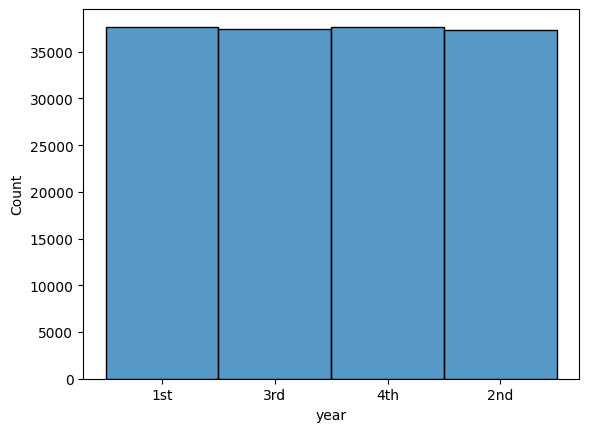

In [146]:
sns.histplot(df['year'])

# Average CGPA by Sleep Quality

In [147]:
df.groupby('sleep_quality')['cgpa'].mean()

sleep_quality
Average    6.991159
Good       7.013745
Poor       6.987189
Name: cgpa, dtype: float64

# Correlation Between Daily Study Hours and CGPA

In [148]:
df['daily_study_hours'].corr(df['cgpa'])

np.float64(-0.005449724676499281)

# Most Frequent Stress Level

In [149]:
df['stress_level'].value_counts()

stress_level
High      50295
Medium    50090
Low       49615
Name: count, dtype: int64

In [150]:
df['stress_level'].value_counts(normalize=True)*100

stress_level
High      33.530000
Medium    33.393333
Low       33.076667
Name: proportion, dtype: float64

# Section 2 : Data Cleaning & Preprocessing(Complex)

## Missing Values Handling

a. Rows containing at least one NaN

In [151]:
df.isnull().sum()

student_id                 0
age                        0
gender                     0
course                     0
year                       0
daily_study_hours          0
daily_sleep_hours          0
screen_time_hours          0
stress_level               0
anxiety_score              0
depression_score           0
academic_pressure_score    0
financial_stress_score     0
social_support_score       0
physical_activity_hours    0
sleep_quality              0
attendance_percentage      0
cgpa                       0
internet_quality           0
burnout_level              0
dtype: int64

There are no missing value in the whole dataset so the operating cannot be perform on them

## Duplicate Detection

In [152]:
df.duplicated().sum()

np.int64(0)

There is no duplicate value in the whole dataset so the operation cannot be perform on the dataset


## Outlier Detection & Treatment


<Axes: >

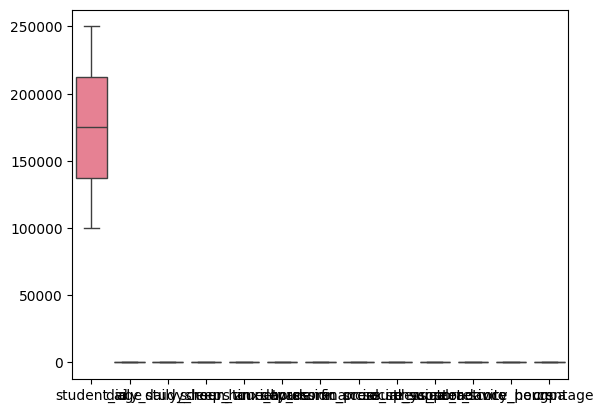

In [153]:
sns.boxplot(df)

There is no outlier in the whole dataset so the ooperation cannot be perform on them

## Encoding Categorical Variables

a. Identify categorical columns

In [154]:
df.select_dtypes(include=['object']).columns

C:\Users\HASEEB\AppData\Local\Temp\ipykernel_4892\549554427.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include=['object']).columns


Index(['gender', 'course', 'year', 'stress_level', 'sleep_quality',
       'internet_quality', 'burnout_level'],
      dtype='str')

Categorical columns usually:

gender
course
sleep_quality
stress_level
burnout_level
internet_quality

Why encoding needed?
Because ML models only understand numbers.

b. One-Hot Encoding

In [155]:
df_dummies = pd.get_dummies(df, columns=['gender','course','internet_quality'], drop_first=True)

label encodeing

In [156]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['burnout_level'] = le.fit_transform(df['burnout_level'])

In [157]:
df['burnout_level']

0         0
1         1
2         0
3         0
4         1
         ..
149995    1
149996    0
149997    0
149998    2
149999    0
Name: burnout_level, Length: 150000, dtype: int64

Ordinal Encodeing

In [158]:
sleep_map = {'Poor':0, 'Average':1, 'Good':2}
stress_map = {'Low':0, 'Medium':1, 'High':2}

df['sleep_quality'] = df['sleep_quality'].map(sleep_map)
df['stress_level'] = df['stress_level'].map(stress_map)

Why ordinal instead of one-hot?
Because categories have natural order.

## Feature Scaling

In [159]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['cgpa','daily_study_hours','screen_time_hours','anxiety_score','depression_score']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [160]:
df[num_cols].mean()

cgpa                -5.580129e-16
daily_study_hours   -1.139237e-16
screen_time_hours    8.801256e-17
anxiety_score       -2.576902e-17
depression_score     1.256240e-16
dtype: float64

In [161]:
df[num_cols].std()

cgpa                 1.000003
daily_study_hours    1.000003
screen_time_hours    1.000003
anxiety_score        1.000003
depression_score     1.000003
dtype: float64

## Datatypes Validation

In [162]:
df.dtypes

student_id                   int64
age                          int64
gender                         str
course                         str
year                           str
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level                 int64
anxiety_score              float64
depression_score           float64
academic_pressure_score      int64
financial_stress_score       int64
social_support_score         int64
physical_activity_hours    float64
sleep_quality                int64
attendance_percentage      float64
cgpa                       float64
internet_quality               str
burnout_level                int64
dtype: object

In [163]:
df

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,-0.465355,6.8,-0.126715,2,1.568648,-0.870460,4,2,6,1.8,1,66.5,1.519830,Good,0
1,100002,20,Male,BTech,3rd,-1.582638,4.7,-1.101884,2,-1.216288,1.569404,8,5,9,1.9,0,55.8,-0.552709,Poor,1
2,100003,24,Female,BCA,4th,-0.696517,4.8,-1.573739,0,-1.216288,0.523748,8,6,3,0.8,2,85.0,0.757782,Good,0
3,100004,21,Male,BSc,4th,-1.505584,6.7,0.156398,2,-0.868171,-0.870460,4,9,9,0.7,0,89.1,-0.604667,Good,0
4,100005,23,Other,BSc,4th,-1.351476,6.7,-0.346914,2,0.524297,0.523748,6,4,4,1.7,2,58.7,0.873244,Good,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,249996,24,Female,BSc,3rd,-1.505584,8.2,1.509052,1,1.220531,1.220852,5,3,10,2.0,2,54.2,0.474901,Good,1
149996,249997,25,Male,BCA,3rd,1.692156,4.8,-1.542282,2,1.568648,-0.870460,10,10,2,0.1,0,53.6,0.111196,Average,0
149997,249998,22,Male,BTech,1st,-1.582638,4.4,-0.598571,2,1.568648,0.872300,6,4,7,1.6,2,90.7,1.606427,Average,0
149998,249999,19,Male,BSc,3rd,-1.544111,4.3,-1.699568,1,0.872414,0.175196,5,7,4,1.1,1,83.9,1.664158,Average,2


In [164]:
df.year.value_counts()

year
1st    37680
4th    37622
3rd    37422
2nd    37276
Name: count, dtype: int64

In [165]:
year_dict = {
    '1st': 1,
    '2nd': 2,
    '3rd': 3,
    '4th': 4
}

df['year'] = df['year'].map(year_dict)
df['cgpa'] = df['cgpa'].astype(float)

In [166]:
df

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1,-0.465355,6.8,-0.126715,2,1.568648,-0.870460,4,2,6,1.8,1,66.5,1.519830,Good,0
1,100002,20,Male,BTech,3,-1.582638,4.7,-1.101884,2,-1.216288,1.569404,8,5,9,1.9,0,55.8,-0.552709,Poor,1
2,100003,24,Female,BCA,4,-0.696517,4.8,-1.573739,0,-1.216288,0.523748,8,6,3,0.8,2,85.0,0.757782,Good,0
3,100004,21,Male,BSc,4,-1.505584,6.7,0.156398,2,-0.868171,-0.870460,4,9,9,0.7,0,89.1,-0.604667,Good,0
4,100005,23,Other,BSc,4,-1.351476,6.7,-0.346914,2,0.524297,0.523748,6,4,4,1.7,2,58.7,0.873244,Good,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,249996,24,Female,BSc,3,-1.505584,8.2,1.509052,1,1.220531,1.220852,5,3,10,2.0,2,54.2,0.474901,Good,1
149996,249997,25,Male,BCA,3,1.692156,4.8,-1.542282,2,1.568648,-0.870460,10,10,2,0.1,0,53.6,0.111196,Average,0
149997,249998,22,Male,BTech,1,-1.582638,4.4,-0.598571,2,1.568648,0.872300,6,4,7,1.6,2,90.7,1.606427,Average,0
149998,249999,19,Male,BSc,3,-1.544111,4.3,-1.699568,1,0.872414,0.175196,5,7,4,1.1,1,83.9,1.664158,Average,2


In [167]:
df.dtypes

student_id                   int64
age                          int64
gender                         str
course                         str
year                         int64
daily_study_hours          float64
daily_sleep_hours          float64
screen_time_hours          float64
stress_level                 int64
anxiety_score              float64
depression_score           float64
academic_pressure_score      int64
financial_stress_score       int64
social_support_score         int64
physical_activity_hours    float64
sleep_quality                int64
attendance_percentage      float64
cgpa                       float64
internet_quality               str
burnout_level                int64
dtype: object

# Section 3: Exploratory Data Analysis (EDA)


1. Distribution of CGPA


<Axes: xlabel='stress_level', ylabel='Count'>

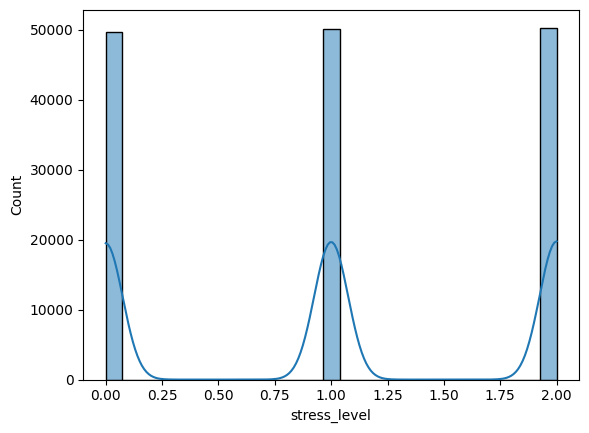

In [168]:
sns.histplot(df['stress_level'], kde = True)

In [169]:
df['cgpa'].skew()

np.float64(0.0013310578315816868)

In [170]:
df['cgpa'].kurt()

np.float64(-1.1994470941617936)

2. Boxplot CGPA by Stress Level

<Axes: xlabel='stress_level', ylabel='cgpa'>

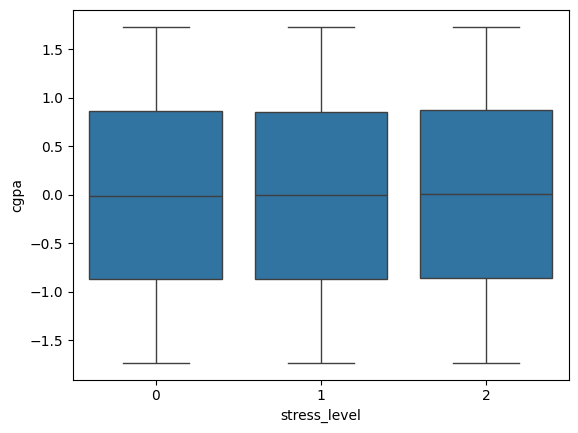

In [171]:
sns.boxplot(x = 'stress_level', y = 'cgpa', data = df)

3. Bar Plot Anxiety by Gender

<Axes: xlabel='gender', ylabel='anxiety_score'>

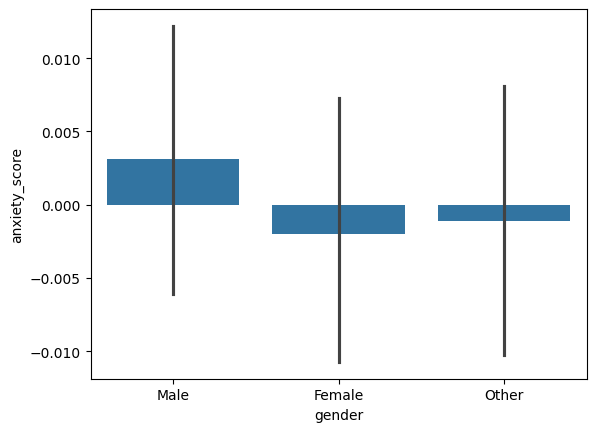

In [172]:
sns.barplot(x = 'gender', y = 'anxiety_score', data = df)

4. Scatter Plot Study Hours vs CGPA

<Axes: xlabel='daily_study_hours', ylabel='cgpa'>

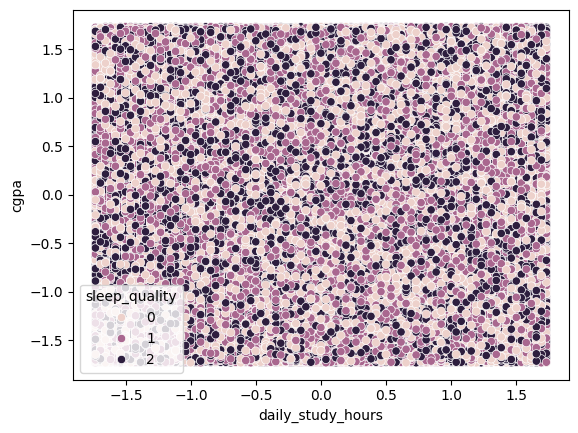

In [173]:
sns.scatterplot(x = 'daily_study_hours', y = 'cgpa', hue = 'sleep_quality', data = df)

5. Burnout by Course

<Axes: xlabel='course'>

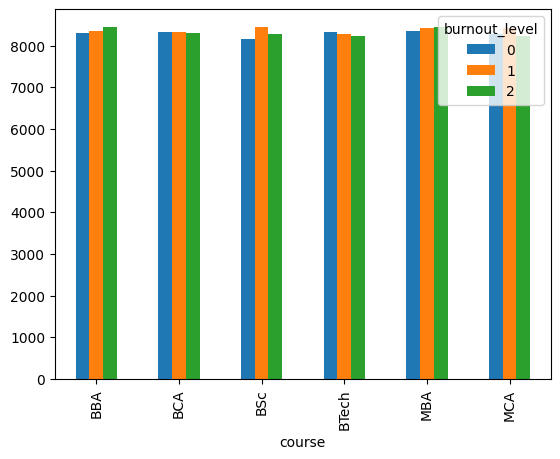

In [174]:
pd.crosstab(df['course'], df['burnout_level']).plot(kind = 'bar')

6. Screen Time Distribution

<Axes: xlabel='screen_time_hours', ylabel='Count'>

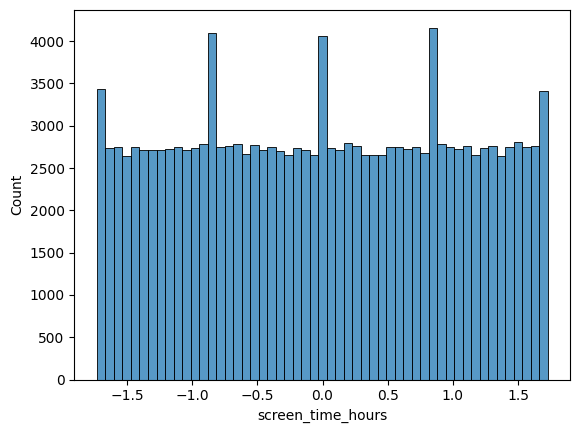

In [175]:
sns.histplot(df['screen_time_hours'])

7. Violin plot of CGPA by Internet_quality

<Axes: xlabel='internet_quality', ylabel='cgpa'>

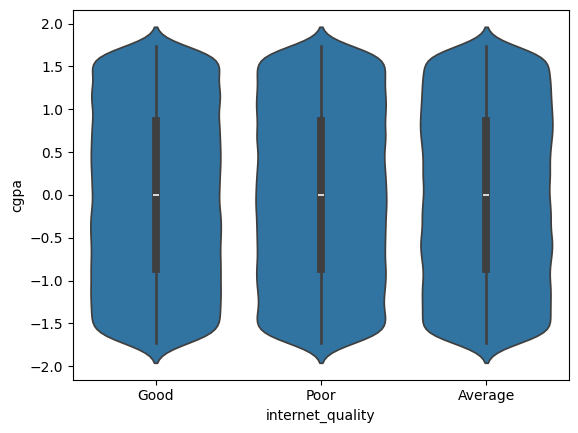

In [176]:
sns.violinplot(x = 'internet_quality', y = 'cgpa', data = df)

8. Correlation Heatmap

In [177]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

ValueError: could not convert string to float: 'Male'

<Figure size 1000x600 with 0 Axes>

9. Pairplot

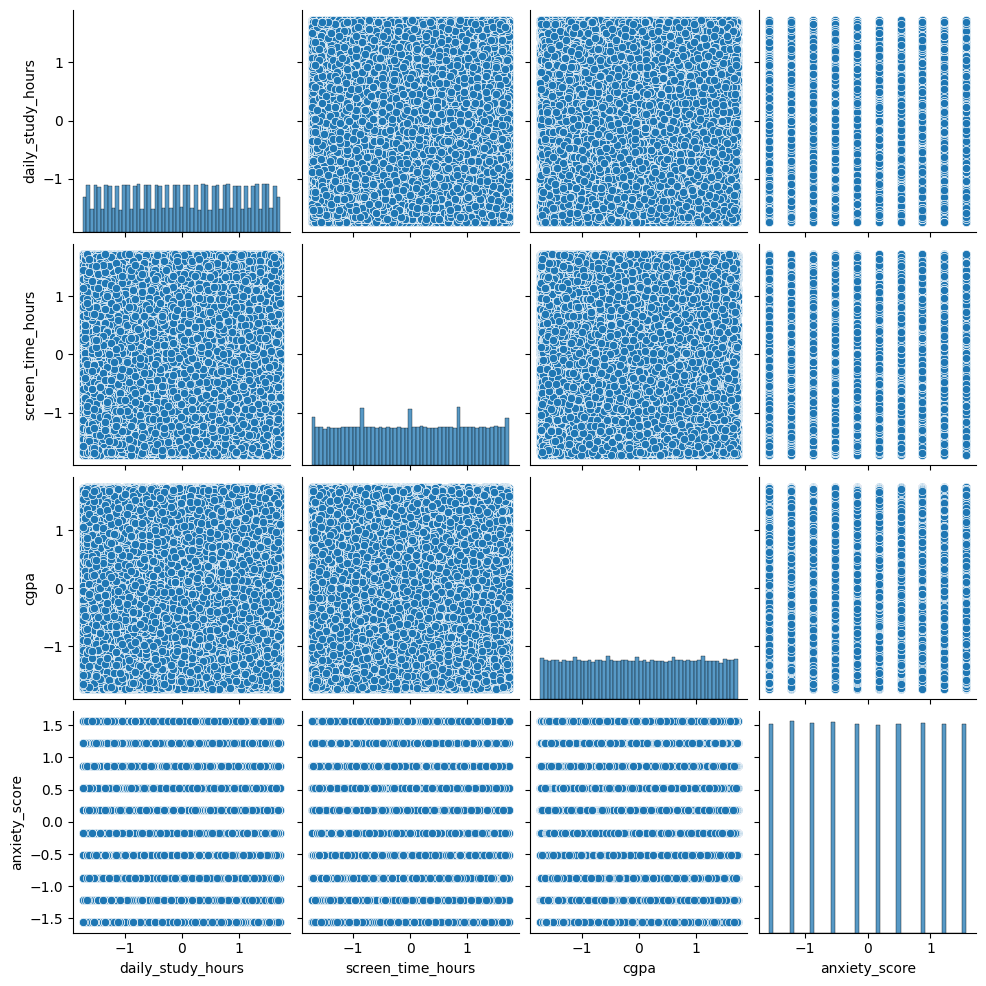

In [ ]:
sns.pairplot(df[['daily_study_hours', 'screen_time_hours', 'cgpa', 'anxiety_score']])

10. Boxplot

<Axes: xlabel='academic_pressure_score', ylabel='burnout_level'>

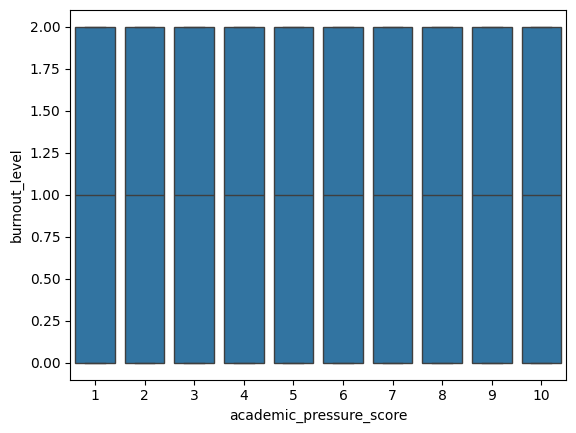

In [ ]:
sns.boxplot(x = 'academic_pressure_score', y = 'burnout_level', data = df)

# LABEL ENCODING


In [178]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['burnout_level'] = le.fit_transform(df['burnout_level'])

In [179]:
df = pd.get_dummies(df)
df.head()

,student_id,age,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,...,gender_Other,course_BBA,course_BCA,course_BSc,course_BTech,course_MBA,course_MCA,internet_quality_Average,internet_quality_Good,internet_quality_Poor
0,100001,23,1,-0.465355,6.8,-0.126715,2,1.568648,-0.870460,4,...,False,False,False,False,True,False,False,False,True,False
1,100002,20,3,-1.582638,4.7,-1.101884,2,-1.216288,1.569404,8,...,False,False,False,False,True,False,False,False,False,True
2,100003,24,4,-0.696517,4.8,-1.573739,0,-1.216288,0.523748,8,...,False,False,True,False,False,False,False,False,True,False
3,100004,21,4,-1.505584,6.7,0.156398,2,-0.868171,-0.870460,4,...,False,False,False,True,False,False,False,False,True,False
4,100005,23,4,-1.351476,6.7,-0.346914,2,0.524297,0.523748,6,...,True,False,False,True,False,False,False,False,True,False


In [180]:
df

,student_id,age,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,...,gender_Other,course_BBA,course_BCA,course_BSc,course_BTech,course_MBA,course_MCA,internet_quality_Average,internet_quality_Good,internet_quality_Poor
0,100001,23,1,-0.465355,6.8,-0.126715,2,1.568648,-0.870460,4,...,False,False,False,False,True,False,False,False,True,False
1,100002,20,3,-1.582638,4.7,-1.101884,2,-1.216288,1.569404,8,...,False,False,False,False,True,False,False,False,False,True
2,100003,24,4,-0.696517,4.8,-1.573739,0,-1.216288,0.523748,8,...,False,False,True,False,False,False,False,False,True,False
3,100004,21,4,-1.505584,6.7,0.156398,2,-0.868171,-0.870460,4,...,False,False,False,True,False,False,False,False,True,False
4,100005,23,4,-1.351476,6.7,-0.346914,2,0.524297,0.523748,6,...,True,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,249996,24,3,-1.505584,8.2,1.509052,1,1.220531,1.220852,5,...,False,False,False,True,False,False,False,False,True,False
149996,249997,25,3,1.692156,4.8,-1.542282,2,1.568648,-0.870460,10,...,False,False,True,False,False,False,False,True,False,False
149997,249998,22,1,-1.582638,4.4,-0.598571,2,1.568648,0.872300,6,...,False,False,False,False,True,False,False,True,False,False
149998,249999,19,3,-1.544111,4.3,-1.699568,1,0.872414,0.175196,5,...,False,False,False,True,False,False,False,True,False,False


In [181]:
df.shape

(150000, 29)

In [182]:
X = df.drop('anxiety_score', axis = 1)
y = df['anxiety_score']
X.columns

Index(['student_id', 'age', 'year', 'daily_study_hours', 'daily_sleep_hours',
       'screen_time_hours', 'stress_level', 'depression_score',
       'academic_pressure_score', 'financial_stress_score',
       'social_support_score', 'physical_activity_hours', 'sleep_quality',
       'attendance_percentage', 'cgpa', 'burnout_level', 'gender_Female',
       'gender_Male', 'gender_Other', 'course_BBA', 'course_BCA', 'course_BSc',
       'course_BTech', 'course_MBA', 'course_MCA', 'internet_quality_Average',
       'internet_quality_Good', 'internet_quality_Poor'],
      dtype='str')

In [183]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


In [184]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [185]:
X_test.head()

,student_id,age,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,depression_score,academic_pressure_score,financial_stress_score,...,gender_Other,course_BBA,course_BCA,course_BSc,course_BTech,course_MBA,course_MCA,internet_quality_Average,internet_quality_Good,internet_quality_Poor
59770,159771,25,4,0.806035,4.7,1.100110,1,-0.173356,4,5,...,True,False,False,False,False,False,True,False,True,False
21362,121363,24,4,0.613400,6.6,1.225938,2,1.569404,3,10,...,False,False,False,False,False,False,True,False,False,True
127324,227325,23,4,0.651927,6.8,0.911368,0,1.220852,6,10,...,False,True,False,False,False,False,False,True,False,False
140509,240510,17,3,-1.351476,5.4,-1.038970,0,1.569404,8,10,...,True,False,False,False,False,True,False,False,True,False
144297,244298,23,2,1.422467,5.3,0.974282,2,-1.567564,3,2,...,False,False,False,False,True,False,False,False,False,True


In [186]:
y_test

59770     0.176180
21362     1.220531
127324    0.872414
140509    0.176180
144297    0.872414
            ...   
30430     1.220531
63244     0.524297
104970   -0.868171
53960    -1.564405
49315    -0.868171
Name: anxiety_score, Length: 30000, dtype: float64

In [187]:
y_pred

array([-0.01279246, -0.02141211,  0.0134025 , ..., -0.01496952,
        0.01578785, -0.02958741], shape=(30000,))

In [189]:
from sklearn.metrics import r2_score,root_mean_squared_error
print("accuracy of model ", r2_score(y_test, y_pred))


accuracy of model  -0.0005037037884960682


<Axes: xlabel='anxiety_score'>

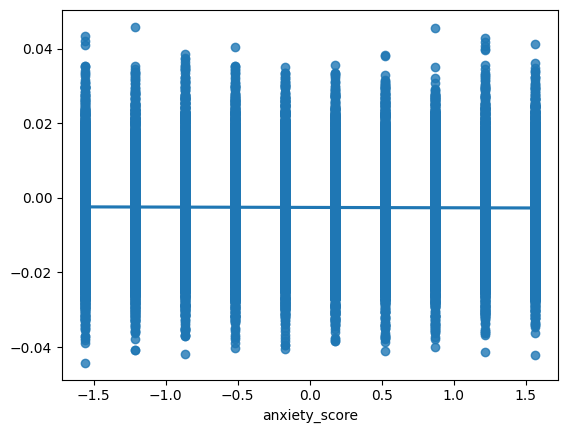

In [190]:
sns.regplot(x = y_test, y = y_pred)

In [193]:
poly = PolynomialFeatures(degree = 2)

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

In [200]:
poly_model = LinearRegression()
poly_model.fit(X_poly_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [203]:
y_pred_poly = poly_model.predict(X_poly_test)
from sklearn.metrics import r2_score, mean_squared_error

print("Polynomial R2: ", r2_score(y_test, y_pred_poly))
print("Polynomial MSE: ", mean_squared_error(y_test, y_pred_poly))

Polynomial R2:  -0.0020590137438063483
Polynomial MSE:  1.001515534503822


In [205]:
y_pred_poly

array([ 0.04443749, -0.002828  , -0.00209594, ..., -0.01753483,
        0.04091227, -0.02157914], shape=(30000,))

<Axes: xlabel='anxiety_score', ylabel='anxiety_score'>

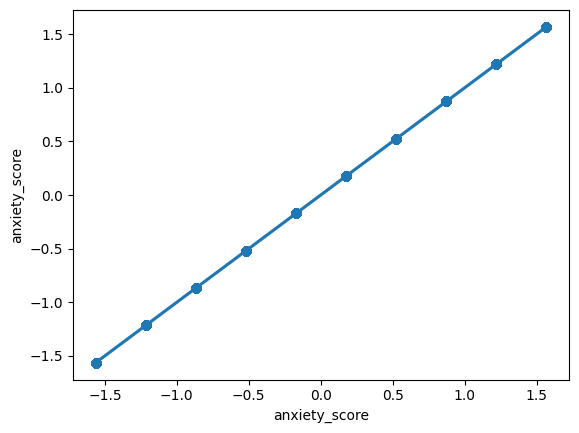

In [206]:
sns.regplot(x = y_test, y = y_test)